In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("../data/processed/tcs_stock_data_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df[["Date", "Close"]]
df.head()

,Date,Close
0,2018-01-01,1322.800049
1,2018-01-02,1315.599976
2,2018-01-03,1319.324951
3,2018-01-04,1328.550049
4,2018-01-05,1344.599976


In [4]:
prophet_df = df.rename(columns={
    "Date": "ds",
    "Close": "y"
})

prophet_df.head()

,ds,y
0,2018-01-01,1322.800049
1,2018-01-02,1315.599976
2,2018-01-03,1319.324951
3,2018-01-04,1328.550049
4,2018-01-05,1344.599976


In [5]:
split_index = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split_index]
test = prophet_df.iloc[split_index:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1580, 2)
Test shape: (395, 2)


In [6]:
model = Prophet()

model.fit(train)

21:32:00 - cmdstanpy - INFO - Chain [1] start processing
21:32:00 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(periods=len(test), freq="B")
future.tail()

,ds
1970,2025-11-27
1971,2025-11-28
1972,2025-12-01
1973,2025-12-02
1974,2025-12-03


In [8]:
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1970,2025-11-27,4865.676455,3382.434672,6271.134167
1971,2025-11-28,4868.808586,3417.059463,6281.123849
1972,2025-12-01,4882.798860,3419.328410,6322.654793
1973,2025-12-02,4888.855094,3403.003197,6325.831131
1974,2025-12-03,4894.730310,3392.908557,6344.900061


In [9]:
forecast_test = forecast[["ds", "yhat"]].tail(len(test)).copy()

forecast_test = forecast_test.reset_index(drop=True)
test = test.reset_index(drop=True)

results = pd.DataFrame({
    "Date": test["ds"],
    "Actual": test["y"],
    "Prophet_Prediction": forecast_test["yhat"]
})

results.head()

,Date,Actual,Prophet_Prediction
0,2024-05-30,3736.100098,3865.658742
1,2024-05-31,3670.949951,3865.495964
2,2024-06-03,3702.850098,3871.102981
3,2024-06-04,3715.000000,3874.834297
4,2024-06-05,3746.449951,3878.593306


In [10]:
mae = mean_absolute_error(results["Actual"], results["Prophet_Prediction"])
print("MAE:", mae)

MAE: 822.1982804497145


In [11]:
rmse = np.sqrt(mean_squared_error(results["Actual"], results["Prophet_Prediction"]))
print("RMSE:", rmse)

RMSE: 1025.9634513886301


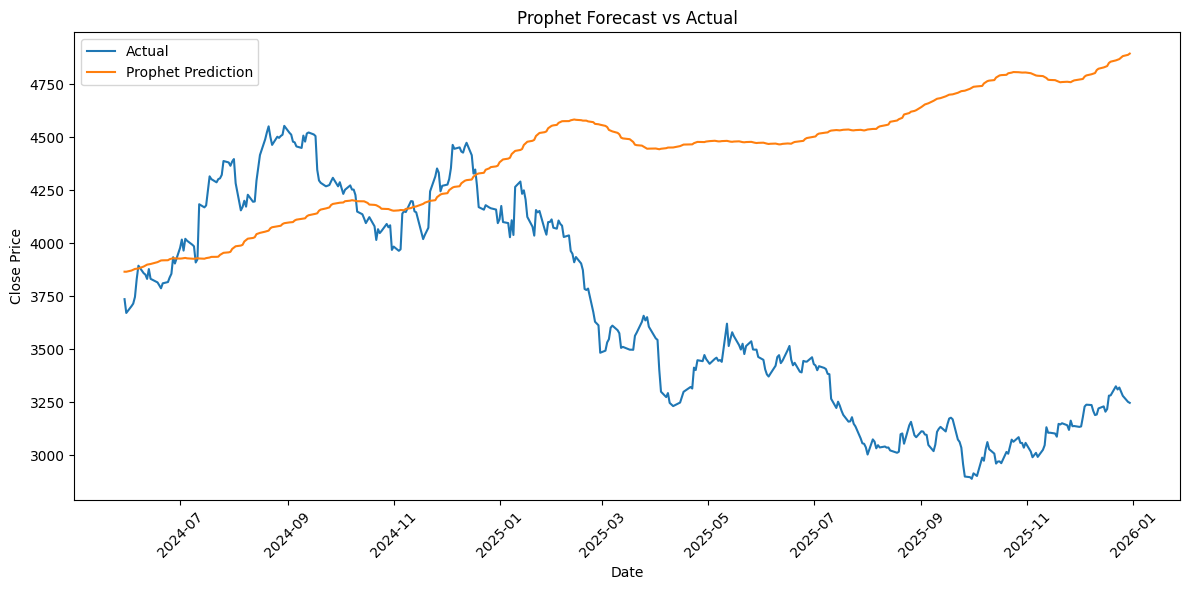

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(results["Date"], results["Actual"], label="Actual")
plt.plot(results["Date"], results["Prophet_Prediction"], label="Prophet Prediction")

plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

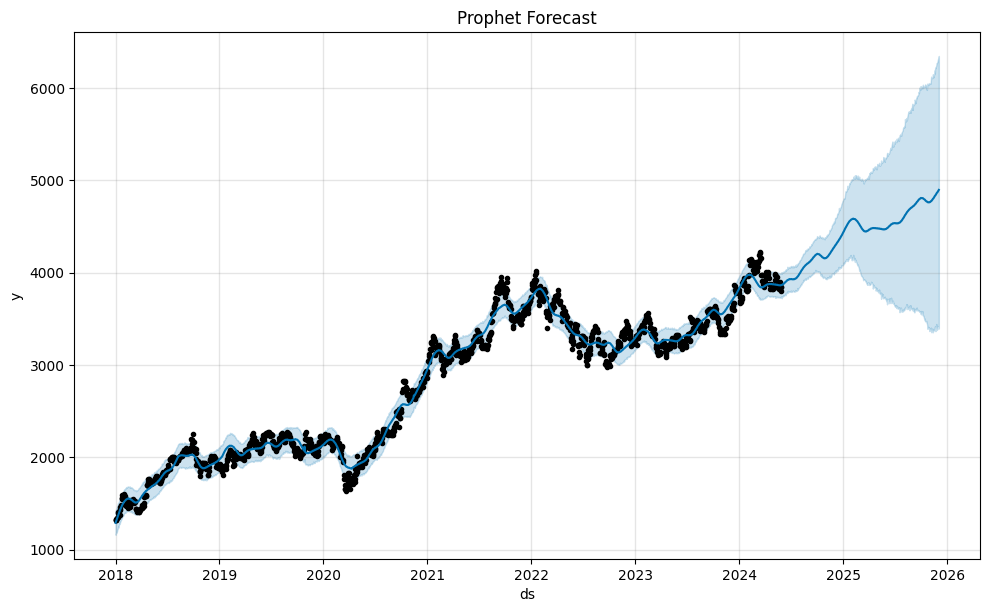

In [13]:
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

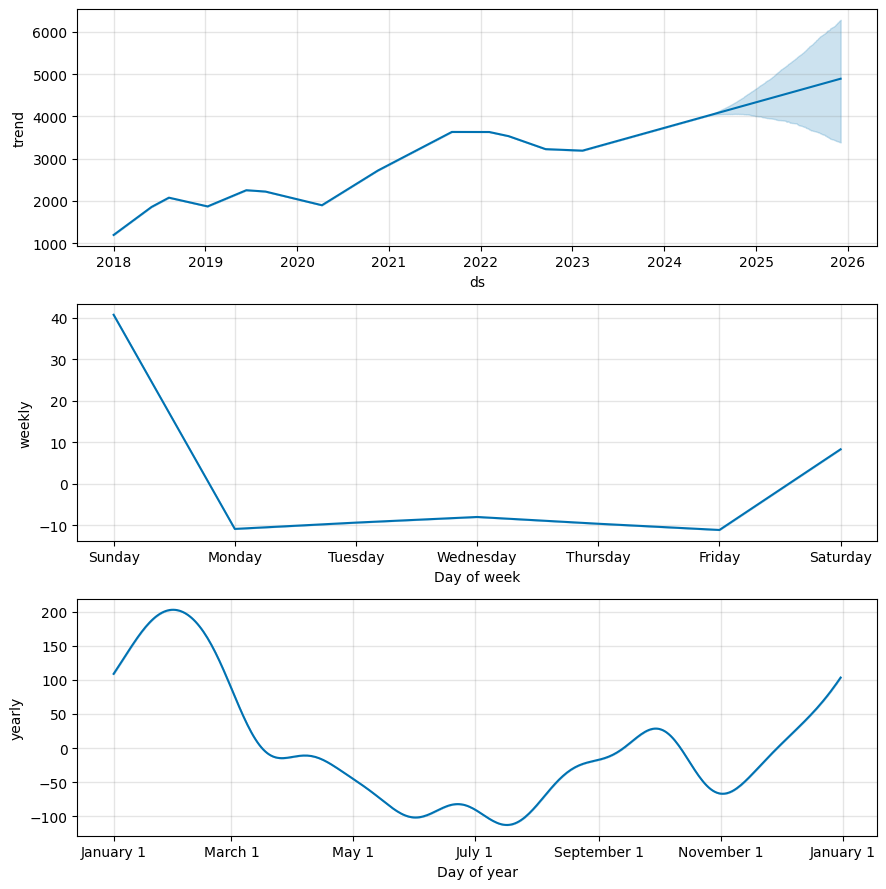

In [14]:
fig2 = model.plot_components(forecast)
plt.show()

In [15]:
results.to_csv("../data/processed/prophet_predictions.csv", index=False)

In [16]:
forecast.to_csv("../data/processed/prophet_full_forecast.csv", index=False)